In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_parquet("data/downstream2025.parquet")

In [11]:
gics_map = {
    10: 'Energy',
    15: 'Materials',
    20: 'Industrials',
    25: 'Consumer Discretionary',
    30: 'Consumer Staples',
    35: 'Health Care',
    40: 'Financials',
    45: 'Information Technology',
    50: 'Communication Services',
    55: 'Utilities',
    60: 'Real Estate',
}

df['gics_name'] = df['gics'].astype(int).map(gics_map)

In [12]:
# 'momentum-up-30'
scenarios = [ 'momentum-up-30', 'value-up-30', 'value-down-30','momentum-down-30']
#scenarios = ['momentum-up-30_', 'vol-down-50_', 'value-up-30_', 'value-down-30_','momentum-down-30_']
COLORS = ['#B50063', '#2ca02c', '#ff7f0e', '#9467bd']

In [13]:
def get_stress_pv(df: pd.DataFrame, df_stress: pd.DataFrame,
                  horizon: int = 22, seed: int | None = None) -> pd.DataFrame:
    rng   = np.random.default_rng(seed)
    df    = df.dropna(subset=['mcap'])
    pools = {cid: g['returns'].to_numpy() for cid, g in df_stress.groupby('csecid')}

    out = {}
    for date, day in df.groupby('date'):
        w     = (day['mcap'] / day['mcap'].sum()).to_numpy() # (S, )
        assert np.isclose(w.sum(), 1.0), f"weights sum to {w.sum()} on {date}"
        paths = np.stack([rng.choice(pools[c], horizon, replace=False)
                          for c in day['csecid']]) # for each stock sample 22 returns shape == (S, horizon)
        stock_pv  = np.prod(1 + paths, axis=1) - 1            # (S,) monthly return per stock
        out[date] = w @ stock_pv

    return pd.Series(out, name='pv').rename_axis('date').reset_index()

def get_sector_pv(df, df_stress, horizon=22, seed=None):
    rng   = np.random.default_rng(seed)
    df    = df.dropna(subset=['mcap'])

    pools = {cid: g['returns'].to_numpy() for cid, g in df_stress.groupby('csecid')}
    rows = []
    for date, day in df.groupby('date'):
        w   = (day['mcap'] / day['mcap'].sum()).to_numpy()
        assert np.isclose(w.sum(), 1.0), f"weights sum to {w.sum()} on {date}"
        paths = np.stack([rng.choice(pools[c], horizon, replace=False) for c in day['csecid']])
        stock_pv = np.prod(1 + paths, axis=1) - 1            # (S,)
        for k, idx in day.groupby('gics_name').indices.items():
            rows.append((date, k, w[idx] @ stock_pv[idx]))
    return pd.DataFrame(rows, columns=['date', 'gics_name', 'pv'])

In [14]:
# compute stress PV (portfolio + per-sector) for every scenario, plus uncon baseline
uncon_pv = get_stress_pv(df, pd.read_parquet("uncon.parquet"), horizon=1, seed=0)

stress_pvs = {}   # name -> per-date portfolio pv
sector_pvs = {}   # name -> per-date per-sector pv
for name in scenarios:
    ds = pd.read_parquet(f"{name}.parquet")
    stress_pvs[name] = get_stress_pv(df, ds, horizon=1, seed=0)
    sector_pvs[name] = get_sector_pv(df, ds, horizon=1, seed=0)
    print(f"{name:18s} mean PV {stress_pvs[name]['pv'].mean() * 100:+.2f}%")

momentum-up-30     mean PV +4.44%
value-up-30        mean PV -30.63%
value-down-30      mean PV +25.47%
momentum-down-30   mean PV -3.33%


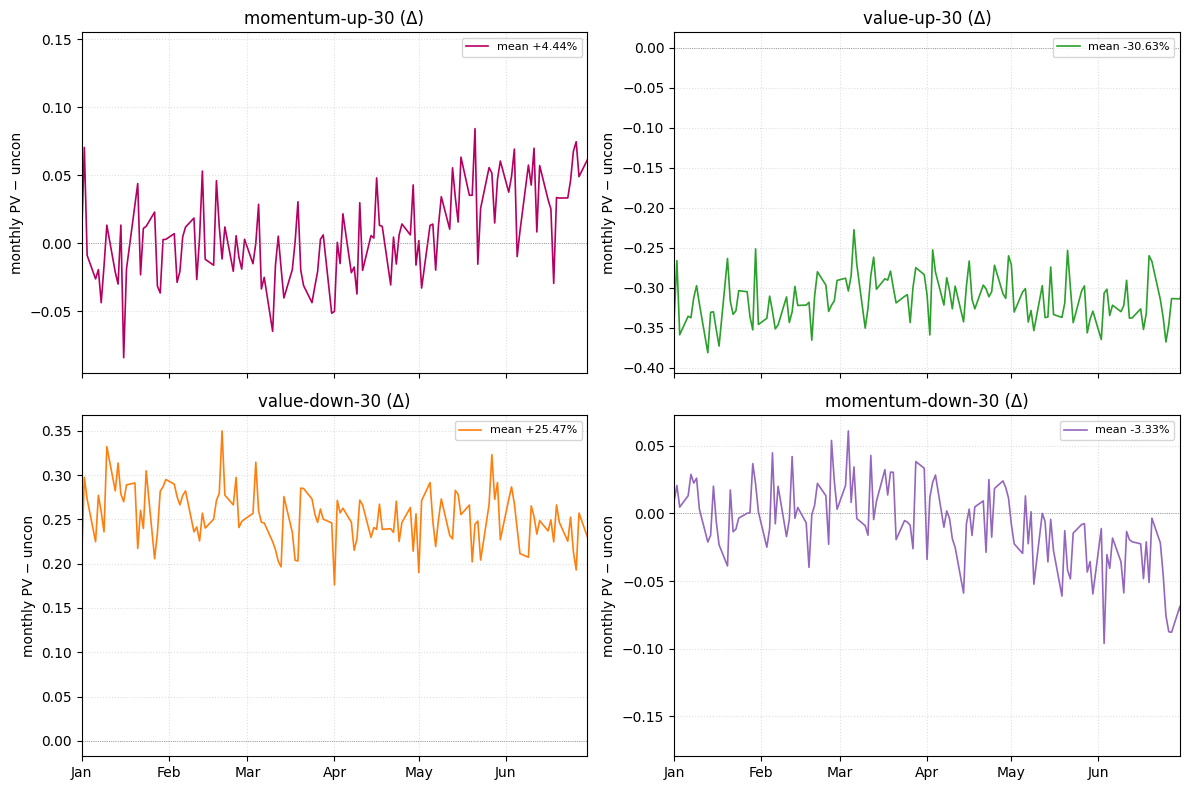

In [15]:
# plot 1: stress portfolio PV delta vs uncon, one subplot per scenario (independent y-scale)
import matplotlib.dates as mdates

xlim = (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-06-30"))   # half year

n = len(scenarios)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                         sharex=True, sharey=False)   # each scenario autoscales y
axes = np.atleast_1d(axes).ravel()
for ax, (name, pv), color in zip(axes, stress_pvs.items(), COLORS):
    delta = pv['pv'].values - uncon_pv['pv'].values
    m = pv['pv'].mean()                                   # legend: scenario's own mean PV
    ax.plot(pv['date'], delta, color=color, lw=1.2, label=f"mean {m * 100:+.2f}%")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"{name} (Δ)")
    ax.set_ylabel("monthly PV − uncon")
    ax.grid(True, ls=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
for ax in axes[n:]:                # hide unused panels
    ax.set_visible(False)
fig.tight_layout()
plt.show()

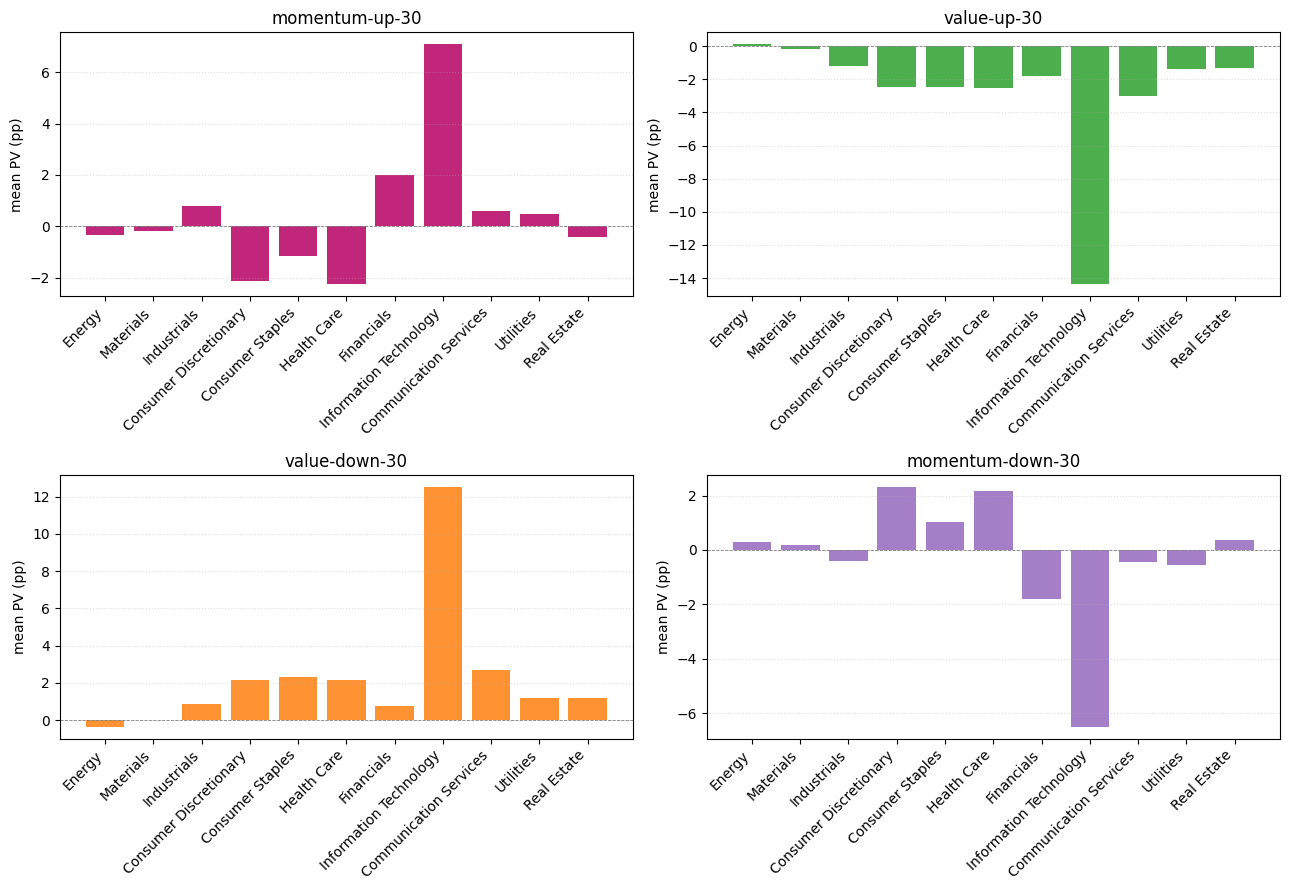

In [16]:
# plot 2: per-sector mean PV, one subplot per scenario (independent y-scale)
means = {name: sp.groupby('gics_name')['pv'].mean() for name, sp in sector_pvs.items()}
sectors = [s for s in gics_map.values() if s in next(iter(means.values())).index]

n = len(scenarios)
ncols = 2
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.5 * nrows),
                         sharex=False, sharey=False)   # each subplot keeps its own x/y axis
axes = np.atleast_1d(axes).ravel()
for ax, name, color in zip(axes, scenarios, COLORS):
    vals = [means[name].get(s, np.nan) * 100 for s in sectors]
    ax.bar(sectors, vals, color=color, alpha=0.85)
    ax.set_title(name)
    ax.set_ylabel("mean PV (pp)")
    ax.axhline(0, color="grey", lw=0.6, ls="--")
    ax.grid(True, ls=":", alpha=0.4, axis='y')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.get_xticklabels(), ha='right')
for ax in axes[n:]:                # hide unused panels
    ax.set_visible(False)
fig.tight_layout()
plt.show()